<a href="https://colab.research.google.com/github/akul-bharadwaj/EDA_NYC_Taxi_Analysis/blob/main/EDA_NYC_Taxi_Analysis_Akul_Bharadwaj_B_H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries

In [ ]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/APAGAI-Assignment-EDA/Starter_Notebook-EDA_NYC_Taxi/Datasets_and_Dictionary/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/APAGAI-Assignment-EDA/Starter_Notebook-EDA_NYC_Taxi/Datasets_and_Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)

        # Create date and hour columns for grouping (date AND hour)
        month_df["pickup_date"] = month_df["tpep_pickup_datetime"].dt.date
        month_df["pickup_hour"] = month_df["tpep_pickup_datetime"].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for d in month_df["pickup_date"].unique():
            day_df = month_df[month_df["pickup_date"] == d]

            # Iterate through each hour of the selected date
            for h in range(24):
                hour_data = day_df[day_df["pickup_hour"] == h]

                if len(hour_data) == 0:
                    continue

                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac=0.05, random_state=42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)

        print(f"Done sampling: {file_name} | sampled rows so far = {len(df)}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Done sampling: 2023-9.parquet | sampled rows so far = 140875
Done sampling: 2023-5.parquet | sampled rows so far = 285333
Done sampling: 2023-6.parquet | sampled rows so far = 448243
Done sampling: 2023-2.parquet | sampled rows so far = 616939
Done sampling: 2023-1.parquet | sampled rows so far = 769026
Done sampling: 2023-8.parquet | sampled rows so far = 912808
Done sampling: 2023-7.parquet | sampled rows so far = 1086876
Done sampling: 2023-10.parquet | sampled rows so far = 1261131
Done sampling: 2023-12.parquet | sampled rows so far = 1427840
Done sampling: 2023-3.parquet | sampled rows so far = 1591626
Done sampling: 2023-4.parquet | sampled rows so far = 1731267
Done sampling: 2023-11.parquet | sampled rows so far = 1896400


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')

# Drop helper cols
for c in ["pickup_date", "pickup_hour"]:
    if c in df.columns:
        df = df.drop(columns=[c])

# Cap total rows to ~250k–300k
TARGET_MAX = 300_000
TARGET_MIN = 250_000

n = len(df)
print("Rows before final cap:", n)

if n > TARGET_MAX:
    df = df.sample(n=TARGET_MAX, random_state=42).reset_index(drop=True)
    print(f"Capped to {TARGET_MAX} rows.")
else:
    print("No capping needed (already <= 300k).")

if len(df) < TARGET_MIN:
    print(f"Warning: only {len(df)} rows (< {TARGET_MIN}). Consider increasing frac in sampling.")

print("Rows after final cap:", len(df))

# Save to Parquet
df.to_parquet("nyc_taxi_sampled_300k.parquet", index=False, compression="snappy")

Rows before final cap: 1896400
Capped to 300000 rows.
Rows after final cap: 300000


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df_sampled_300k = pd.read_parquet("/content/drive/MyDrive/APAGAI-Assignment-EDA/Starter_Notebook-EDA_NYC_Taxi/Datasets_and_Dictionary/trip_records/nyc_taxi_sampled_300k.parquet")

In [ ]:
# df.head()
df_sampled_300k.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-12-26 08:37:08,2023-12-26 08:42:01,1.0,1.07,1.0,N,238,239,1,7.9,0.0,0.5,2.38,0.00,1.0,14.28,2.5,0.00,NaN
1,2,2023-09-09 14:47:50,2023-09-09 15:31:17,1.0,18.11,2.0,N,132,107,2,70.0,0.0,0.5,0.00,6.94,1.0,82.69,2.5,1.75,NaN
2,2,2023-10-13 16:46:26,2023-10-13 16:59:05,1.0,1.54,1.0,N,140,142,1,12.1,2.5,0.5,3.72,0.00,1.0,22.32,2.5,0.00,NaN
3,1,2023-07-10 12:08:14,2023-07-10 12:17:15,1.0,1.80,1.0,N,239,75,1,11.4,2.5,0.5,4.60,0.00,1.0,20.00,2.5,0.00,NaN
4,2,2023-11-08 15:38:53,2023-11-08 15:56:51,1.0,2.61,1.0,N,186,113,1,17.7,0.0,0.5,4.34,0.00,1.0,26.04,2.5,0.00,NaN


In [ ]:
# df.info()
df_sampled_300k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289704 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289704 non-null  float64       
 6   store_and_fwd_flag     289704 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df_sampled_300k = df_sampled_300k.reset_index(drop=True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns

c1, c2 = "Airport_fee", "airport_fee"

# Combine by taking Airport_fee when present, otherwise airport_fee
df_sampled_300k["airport_fee"] = df_sampled_300k[c1].combine_first(df[c2]).fillna(0)

# Drop the duplicate column
df_sampled_300k = df_sampled_300k.drop(columns=[c1])

df_sampled_300k["airport_fee"].notna().sum()

np.int64(300000)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
negative_fare_amount = df_sampled_300k[df_sampled_300k["fare_amount"] < 0]
negative_fare_amount.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [ ]:
df_sampled_300k["fare_amount"].unique()

array([ 7.9 , 70.  , 12.1 , ..., 70.22, 36.52, 54.07])

Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
df_sampled_300k["RatecodeID"].unique()

array([ 1.,  2., nan,  5.,  3., 99.,  4.])

In [ ]:
# Find which columns have negative values
money_cols = ["fare_amount","extra","mta_tax","tip_amount","tolls_amount",
             "improvement_surcharge","total_amount","congestion_surcharge","airport_fee"]
money_cols = [c for c in money_cols if c in df_sampled_300k.columns]
(df_sampled_300k[money_cols] < 0).sum().sort_values(ascending=False)

,0
mta_tax,9
total_amount,9
improvement_surcharge,9
congestion_surcharge,6
airport_fee,3
fare_amount,0
tolls_amount,0
extra,0
tip_amount,0


In [ ]:
# fix these negative values
bad_money = (df_sampled_300k[money_cols] < 0).any(axis=1)
df_sampled_300k.loc[bad_money, money_cols].head(10)

,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
14296,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.25,-2.5,-1.25
48075,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
66010,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
70515,0.0,0.0,-0.5,0.0,0.0,-1.0,-2.75,0.0,-1.25
72012,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
128079,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
139063,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
184046,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
240442,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00


In [ ]:
df_sampled_300k = df_sampled_300k.loc[~bad_money].reset_index(drop=True)

df_sampled_300k.shape

(299991, 19)

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportion = df_sampled_300k.isna().mean().sort_values(ascending=False)
missing_proportion[missing_proportion > 0]

,0
store_and_fwd_flag,0.034321
RatecodeID,0.034321
passenger_count,0.034321
congestion_surcharge,0.034321


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
df_sampled_300k[df_sampled_300k["passenger_count"].isna()].head()

# Impute NaN values in 'passenger_count' (pc)
pc_mode = df_sampled_300k["passenger_count"].mode(dropna=True)[0]
df_sampled_300k["passenger_count"] = df_sampled_300k["passenger_count"].fillna(pc_mode)

Did you find zeroes in passenger_count? Handle these.

In [ ]:
df_sampled_300k.loc[df_sampled_300k["passenger_count"] == 0, "passenger_count"] = pc_mode

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID' (rc)
rc_mode = df_sampled_300k["RatecodeID"].mode(dropna=True)[0]
df_sampled_300k["RatecodeID"] = df_sampled_300k["RatecodeID"].fillna(rc_mode)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge (cs)
cs_mode = df_sampled_300k["congestion_surcharge"].mode(dropna=True)[0]
df_sampled_300k["congestion_surcharge"] = df_sampled_300k["congestion_surcharge"].fillna(cs_mode)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values
remaining = df_sampled_300k.isna().sum()
remaining[remaining > 0]

,0
store_and_fwd_flag,10296


In [ ]:
df_sampled_300k["store_and_fwd_flag"] = df_sampled_300k["store_and_fwd_flag"].fillna("N")

In [ ]:
df_sampled_300k.isna().sum().sum()

np.int64(0)

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df_sampled_300k.describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T


,count,mean,min,1%,5%,50%,95%,99%,max,std
VendorID,299991.0,1.732432,1.0,1.0,1.0,2.0,2.0,2.0,6.0,0.447634
tpep_pickup_datetime,299991,2023-07-02 20:43:21.076145,2023-01-01 00:04:34,2023-01-05 16:42:19.300000,2023-01-20 19:34:28,2023-06-27 12:12:36,2023-12-12 23:03:21.500000,2023-12-27 10:12:45,2023-12-31 23:51:50,NaN
tpep_dropoff_datetime,299991,2023-07-02 21:00:51.457374,2023-01-01 00:13:27,2023-01-05 17:03:07.100000,2023-01-20 19:49:50,2023-06-27 12:36:46,2023-12-12 23:15:22,2023-12-27 10:32:33.100000,2024-01-01 12:29:40,NaN
passenger_count,299991.0,1.371041,1.0,1.0,1.0,1.0,3.0,5.0,8.0,0.863111
trip_distance,299991.0,3.592797,0.0,0.0,0.46,1.8,15.315,20.24,35482.69,67.291705
RatecodeID,299991.0,1.614502,1.0,1.0,1.0,1.0,2.0,5.0,99.0,7.287491
PULocationID,299991.0,165.20904,1.0,24.0,48.0,162.0,249.0,263.0,265.0,64.057204
DOLocationID,299991.0,164.166052,1.0,9.0,43.0,162.0,261.0,264.0,265.0,69.84995
payment_type,299991.0,1.163112,0.0,0.0,1.0,1.0,2.0,3.0,4.0,0.507501
fare_amount,299991.0,19.820537,0.0,4.4,5.8,13.5,70.0,77.2,1375.0,18.229214


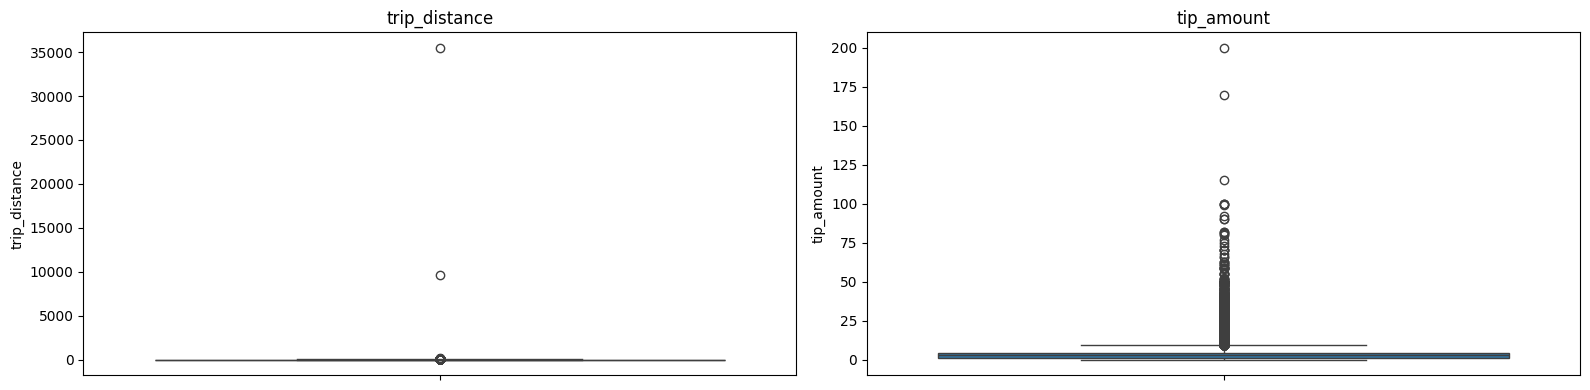

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.boxplot(y=df_sampled_300k["trip_distance"], ax=axes[0])
axes[0].set_title("trip_distance")

sns.boxplot(y=df_sampled_300k["tip_amount"], ax=axes[1])
axes[1].set_title("tip_amount")

plt.tight_layout()
plt.show()

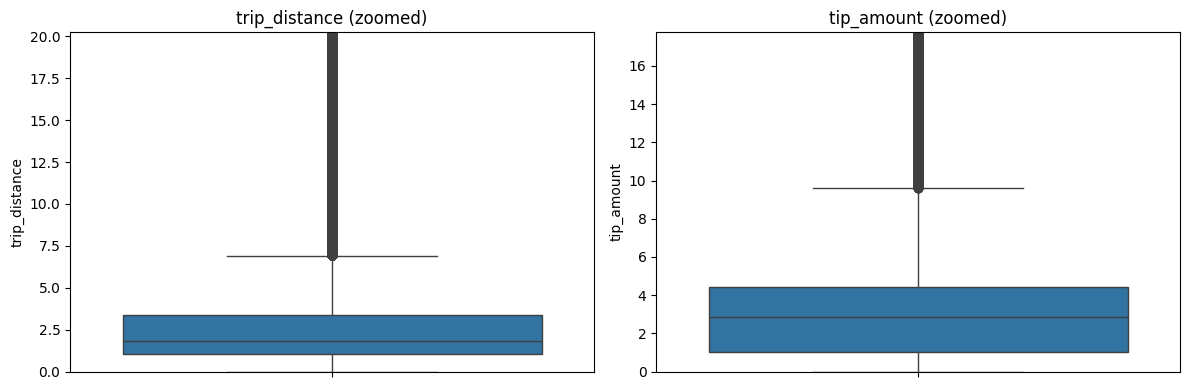

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df_sampled_300k["trip_distance"], ax=axes[0])
axes[0].set_title("trip_distance (zoomed)")
axes[0].set_ylim(0, df_sampled_300k["trip_distance"].quantile(0.99))

sns.boxplot(y=df_sampled_300k["tip_amount"], ax=axes[1])
axes[1].set_title("tip_amount (zoomed)")
axes[1].set_ylim(0, df_sampled_300k["tip_amount"].quantile(0.99))

plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6
df_sampled_300k_cleaned = df_sampled_300k[df_sampled_300k["passenger_count"] <= 6].reset_index(drop=True)

In [ ]:
# Continue with outlier handling
tiny = 0.01  # "nearly zero" distance threshold

mask1 = (df_sampled_300k_cleaned["trip_distance"] <= tiny) & (df_sampled_300k_cleaned["fare_amount"] > 300)
mask2 = (df_sampled_300k_cleaned["trip_distance"] == 0) & (df_sampled_300k_cleaned["fare_amount"] == 0) & (df_sampled_300k_cleaned["PULocationID"] != df_sampled_300k_cleaned["DOLocationID"])
mask3 = (df_sampled_300k_cleaned["trip_distance"] > 250)
mask4 = (df_sampled_300k_cleaned["payment_type"] == 0)
mask5 = (df_sampled_300k_cleaned["tpep_dropoff_datetime"] < df_sampled_300k_cleaned["tpep_pickup_datetime"])
tip_cap = df_sampled_300k_cleaned["tip_amount"].quantile(0.999)
mask6 = df_sampled_300k_cleaned["tip_amount"] > tip_cap

df_sampled_300k_cleaned_and_handled = df_sampled_300k_cleaned.loc[~(mask1 | mask2 | mask3 | mask4 | mask5 | mask6)].reset_index(drop=True)

In [ ]:
# Do any columns need standardising?
df_sampled_300k['store_and_fwd_flag'].unique()

array(['N', 'Y'], dtype=object)

In [ ]:
df_sampled_300k_cleaned_and_handled.dtypes

,0
VendorID,int64
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,int64


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df_sampled_300k_cleaned_and_handled.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [ ]:
# Categorise columns into numerical and categorical

df_eda = df_sampled_300k_cleaned_and_handled.copy()

categorical_cols = [
    "VendorID", "RatecodeID", "PULocationID", "DOLocationID", "payment_type", "store_and_fwd_flag"
]

datetime_cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime"]

numerical_cols = [
    "passenger_count", "trip_distance", "pickup_hour", "trip_duration",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
    "improvement_surcharge", "total_amount", "congestion_surcharge", "airport_fee"
]

categorical_cols, numerical_cols, datetime_cols

(['VendorID',
  'RatecodeID',
  'PULocationID',
  'DOLocationID',
  'payment_type',
  'store_and_fwd_flag'],
 ['passenger_count',
  'trip_distance',
  'pickup_hour',
  'trip_duration',
  'fare_amount',
  'extra',
  'mta_tax',
  'tip_amount',
  'tolls_amount',
  'improvement_surcharge',
  'total_amount',
  'congestion_surcharge',
  'airport_fee'],
 ['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = (
    df_eda["tpep_pickup_datetime"].dt.hour
    .value_counts()
    .sort_index()
    .reset_index()
)
hourly_pickups.columns = ["hour", "pickups"]
hourly_pickups

,hour,pickups
0,0,8010
1,1,5384
2,2,3595
3,3,2321
4,4,1483
5,5,1556
6,6,3811
7,7,7746
8,8,10707
9,9,12389


In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
days_of_the_week_pickups = (
    df_eda["tpep_pickup_datetime"].dt.day_name()
    .value_counts()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    .reset_index()
)
days_of_the_week_pickups.columns = ["day", "pickups"]
days_of_the_week_pickups

,day,pickups
0,Monday,36200
1,Tuesday,42081
2,Wednesday,44366
3,Thursday,45339
4,Friday,43112
5,Saturday,42017
6,Sunday,36306


In [ ]:
# Show the monthly trends in pickups
monthly_pickups = (
    df_eda["tpep_pickup_datetime"].dt.month
    .value_counts()
    .sort_index()
    .reset_index()
)
monthly_pickups.columns = ["month", "pickups"]
monthly_pickups

,month,pickups
0,1,23460
1,2,22048
2,3,26218
3,4,25139
4,5,26700
5,6,25179
6,7,21985
7,8,21356
8,9,20972
9,10,26195


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
fin_cols = ["fare_amount", "tip_amount", "total_amount", "trip_distance"]
fin_summary = df_eda[fin_cols].describe().T
fin_summary["zeros"] = (df_eda[fin_cols] == 0).sum().values
fin_summary["negatives"] = (df_eda[fin_cols] < 0).sum().values
fin_summary

,count,mean,std,min,25%,50%,75%,max,zeros,negatives
fare_amount,289421.0,19.626760,17.772745,0.0,9.30,13.50,21.90,1375.00,79,0
tip_amount,289421.0,3.541898,3.817801,0.0,1.00,2.86,4.45,30.00,64685,0
total_amount,289421.0,28.714935,22.252333,0.0,15.96,21.00,30.65,1435.19,41,0
trip_distance,289421.0,3.428573,4.481219,0.0,1.05,1.78,3.37,204.86,3553,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
df_fin_nonzero = df_eda[
    (df_eda["fare_amount"] > 0) &
    (df_eda["tip_amount"] >= 0) &
    (df_eda["total_amount"] > 0)
].copy()
df_fin_nonzero.shape

(289342, 19)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [ ]:
# Group data by month and analyse monthly revenue
monthly_revenue = (
    df_fin_nonzero
    .groupby(df_fin_nonzero["tpep_pickup_datetime"].dt.month)["total_amount"]
    .sum()
    .reset_index()
    .rename(columns={"tpep_pickup_datetime": "month", "total_amount": "monthly_revenue"})
)
monthly_revenue.columns = ["month", "monthly_revenue"]
monthly_revenue

,month,monthly_revenue
0,1,642905.26
1,2,595753.07
2,3,734039.73
3,4,719794.71
4,5,774829.09
5,6,730160.70
6,7,630973.92
7,8,627567.23
8,9,625927.27
9,10,771381.51


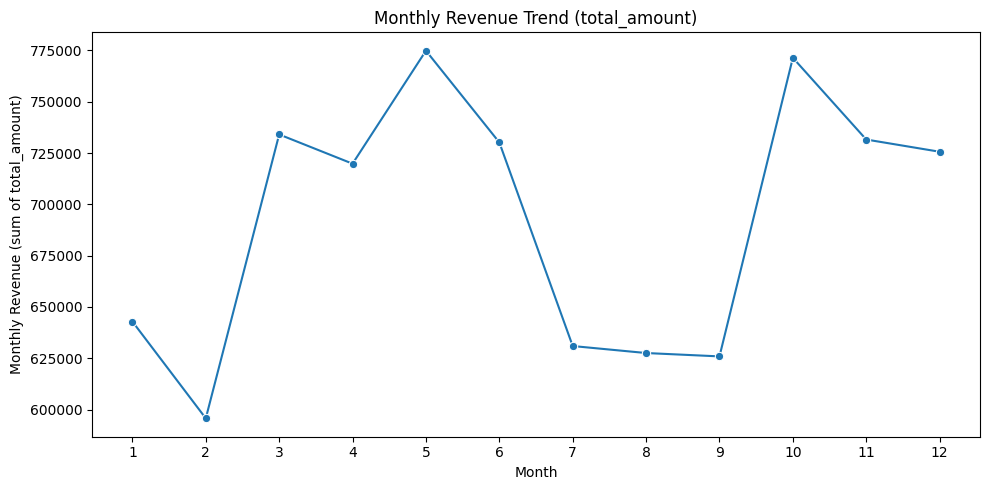

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x="month", y="monthly_revenue", marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Monthly Revenue (sum of total_amount)")
plt.title("Monthly Revenue Trend (total_amount)")
plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter
df_prop = df_fin_nonzero.copy()
df_prop["quarter"] = df_prop["tpep_pickup_datetime"].dt.quarter

quarter_revenue = df_prop.groupby("quarter")["total_amount"].sum()
quarter_prop = (quarter_revenue / quarter_revenue.sum()).reset_index()
quarter_prop.columns = ["quarter", "revenue_proportion"]
quarter_prop

,quarter,revenue_proportion
0,1,0.237374
1,2,0.267707
2,3,0.226757
3,4,0.268161


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [ ]:
# Show how trip fare is affected by distance
df_td = df_sampled_300k_cleaned_and_handled[df_eda["trip_distance"] > 0]

corr_val = df_td["trip_distance"].corr(df_td["fare_amount"])
corr_val


np.float64(0.9450642055452039)

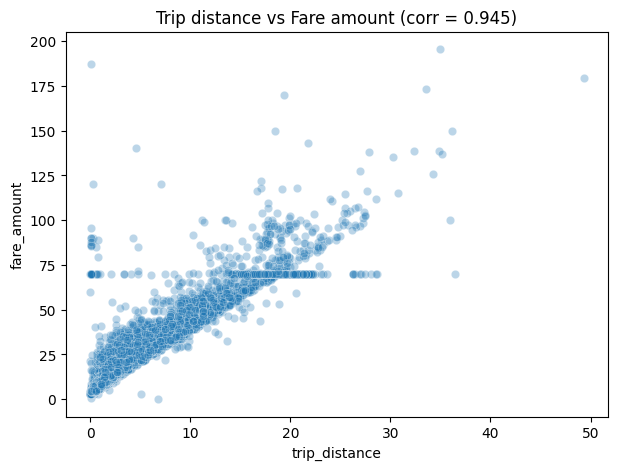

In [ ]:
plot_df = df_td.sample(n=min(20000, len(df_td)), random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df, x="trip_distance", y="fare_amount", alpha=0.3)
plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.title(f"Trip distance vs Fare amount (corr = {corr_val:.3f})")
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
# Show relationship between fare and trip duration
df_td2 = df_eda.copy()
df_td2["trip_duration"] = (
    df_td2["tpep_dropoff_datetime"] -
    df_td2["tpep_pickup_datetime"]
).dt.total_seconds() / 60
df_td2 = df_td2[df_td2["trip_duration"] > 0]

corr_fare_duration = df_td2["fare_amount"].corr(df_td2["trip_duration"])
corr_fare_duration

np.float64(0.25711738821489394)

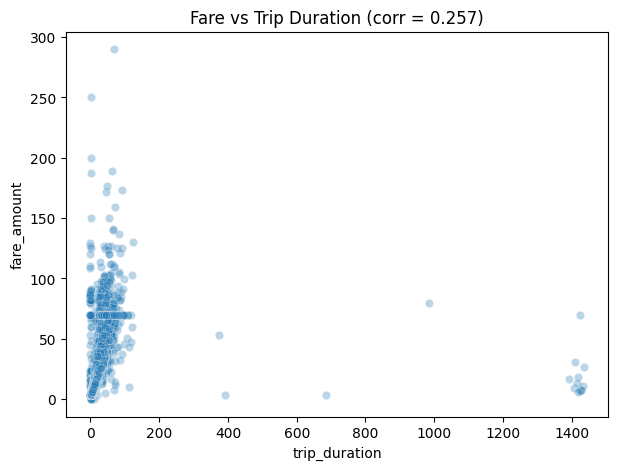

In [ ]:
plot_df_fare_td = df_td2.sample(n=min(20000, len(df_td2)), random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df_fare_td, x="trip_duration", y="fare_amount", alpha=0.3)
plt.title(f"Fare vs Trip Duration (corr = {corr_fare_duration:.3f})")
plt.xlabel("trip_duration")
plt.ylabel("fare_amount")
plt.show()

In [ ]:
# Show relationship between fare and number of passengers
df_fare_pc = df_eda.copy()

corr_fare_passenger = df_fare_pc["fare_amount"].corr(df_fare_pc["passenger_count"])
corr_fare_passenger

np.float64(0.045391052187754764)

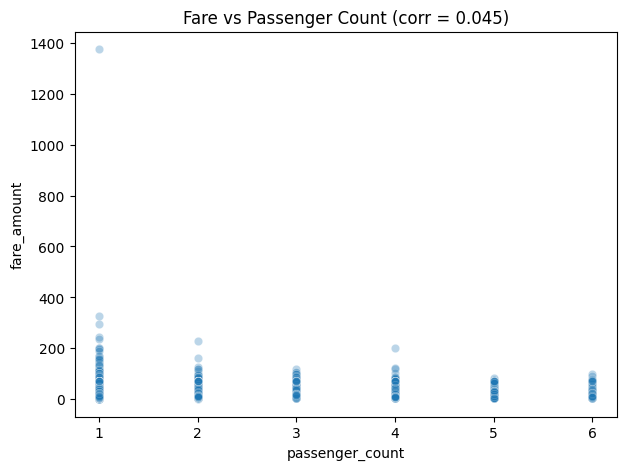

In [ ]:
plot_df_fare_pc = df_fare_pc.sample(n=min(20000, len(df_fare_pc)), random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df_fare_pc, x="passenger_count", y="fare_amount", alpha=0.3)
plt.title(f"Fare vs Passenger Count (corr = {corr_fare_passenger:.3f})")
plt.xlabel("passenger_count")
plt.ylabel("fare_amount")
plt.show()

In [ ]:
# Show relationship between tip and trip distance
df_tip = df_eda[df_eda["trip_distance"] > 0].copy()

corr_tip_distance = df_tip["tip_amount"].corr(df_tip["trip_distance"])
corr_tip_distance

np.float64(0.5956872695874642)

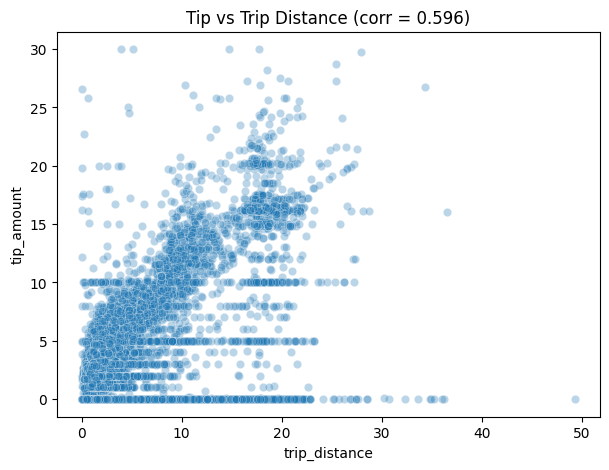

In [ ]:
plot_df_tip = df_tip.sample(n=min(20000, len(df_tip)), random_state=42)

plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df_tip, x="trip_distance", y="tip_amount", alpha=0.3)
plt.title(f"Tip vs Trip Distance (corr = {corr_tip_distance:.3f})")
plt.xlabel("trip_distance")
plt.ylabel("tip_amount")
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

pay_df = (
    df_eda["payment_type"]
    .value_counts()
    .sort_index()
    .rename_axis("payment_type")
    .reset_index(name="count")
)

pay_df["payment_label"] = pay_df["payment_type"].map(payment_map).fillna("Other")

pay_df

,payment_type,count,payment_label
0,1,235924,Credit card
1,2,49919,Cash
2,3,1441,No charge
3,4,2137,Dispute


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file("/content/drive/MyDrive/APAGAI-Assignment-EDA/Starter_Notebook-EDA_NYC_Taxi/Datasets_and_Dictionary/taxi_zones/taxi_zones.shp")
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
zones.to_csv('zo.csv')

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

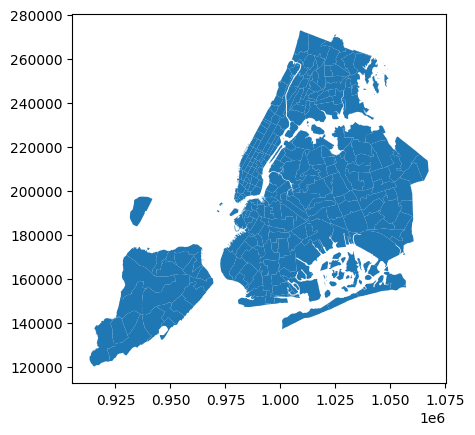

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
df_eda_merged = df_eda.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename(columns={"zone": "PU_zone", "borough": "PU_borough"}).drop(columns=["LocationID"])


In [ ]:
df_eda_merged.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,PU_zone,PU_borough
0,2,2023-12-26 08:37:08,2023-12-26 08:42:01,1.0,1.07,1.0,N,238,239,1,...,0.0,0.5,2.38,0.00,1.0,14.28,2.5,0.00,Upper West Side North,Manhattan
1,2,2023-09-09 14:47:50,2023-09-09 15:31:17,1.0,18.11,2.0,N,132,107,2,...,0.0,0.5,0.00,6.94,1.0,82.69,2.5,1.75,JFK Airport,Queens
2,2,2023-10-13 16:46:26,2023-10-13 16:59:05,1.0,1.54,1.0,N,140,142,1,...,2.5,0.5,3.72,0.00,1.0,22.32,2.5,0.00,Lenox Hill East,Manhattan
3,1,2023-07-10 12:08:14,2023-07-10 12:17:15,1.0,1.80,1.0,N,239,75,1,...,2.5,0.5,4.60,0.00,1.0,20.00,2.5,0.00,Upper West Side South,Manhattan
4,2,2023-11-08 15:38:53,2023-11-08 15:56:51,1.0,2.61,1.0,N,186,113,1,...,0.0,0.5,4.34,0.00,1.0,26.04,2.5,0.00,Penn Station/Madison Sq West,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trip_counts = (
    df_eda_merged.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
)
trip_counts

,PULocationID,trip_count
0,1,33
1,3,7
2,4,311
3,5,2
4,6,3
...,...,...
239,261,1498
240,262,3768
241,263,5660
242,264,2702


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(
    trip_counts,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
).drop(columns=["PULocationID"])

zones_with_trips["trip_count"] = zones_with_trips["trip_count"].fillna(0).astype(int)
zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",33
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",7
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",311
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",2


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

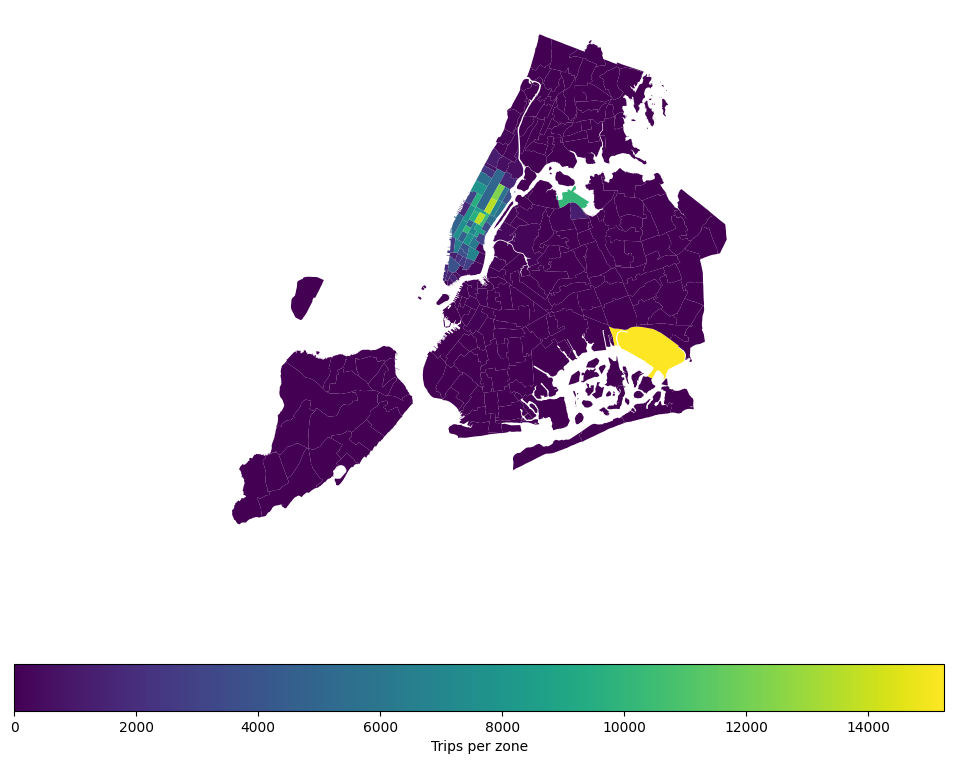

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    legend_kwds={"label": "Trips per zone", "orientation": "horizontal"}
)
ax.set_axis_off()
plt.show()

In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips[["LocationID", "zone", "borough", "trip_count"]].sort_values("trip_count", ascending=False).head(20)

,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,15250
236,237,Upper East Side South,Manhattan,13686
160,161,Midtown Center,Manhattan,13643
235,236,Upper East Side North,Manhattan,12277
161,162,Midtown East,Manhattan,10315
137,138,LaGuardia Airport,Queens,10186
185,186,Penn Station/Madison Sq West,Manhattan,10011
229,230,Times Sq/Theatre District,Manhattan,9611
141,142,Lincoln Square East,Manhattan,9541
169,170,Murray Hill,Manhattan,8534


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day

df_ops = df_eda.copy()

# Ensure trip_duration exists (minutes)
if "trip_duration" not in df_ops.columns:
    df_ops["trip_duration"] = (df_ops["tpep_dropoff_datetime"] - df_ops["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Pickup hour
df_ops["pickup_hour"] = df_ops["tpep_pickup_datetime"].dt.hour

# Keep valid trips
df_ops = df_ops[(df_ops["trip_duration"] > 0) & (df_ops["trip_distance"] > 0)]

# Avg speed (mph) per route per hour: avg(distance) / avg(duration_hours)
route_hour = (
    df_ops.groupby(["pickup_hour", "PULocationID", "DOLocationID"])
    .agg(avg_distance=("trip_distance", "mean"),
         avg_duration_min=("trip_duration", "mean"),
         trips=("trip_distance", "size"))
    .reset_index()
)

route_hour["avg_speed_mph"] = route_hour["avg_distance"] / (route_hour["avg_duration_min"] / 60)

# For each hour, show slowest routes (top 5)
slowest_routes_by_hour = (
    route_hour.sort_values(["pickup_hour", "avg_speed_mph", "trips"], ascending=[True, True, False])
    .groupby("pickup_hour")
    .head(5)
)

slowest_routes_by_hour

,pickup_hour,PULocationID,DOLocationID,avg_distance,avg_duration_min,trips,avg_speed_mph
2656,0,263,68,4.640000,1434.666667,1,0.194052
2430,0,238,243,5.210000,1432.183333,1,0.218268
74,0,43,246,4.280000,723.941667,2,0.354725
1734,0,164,112,4.475000,720.550000,2,0.372632
1516,0,158,234,1.248750,181.245833,8,0.413389
...,...,...,...,...,...,...,...
60704,23,113,4,1.500000,723.191667,2,0.124448
62068,23,170,230,0.918750,182.991667,8,0.301243
62436,23,231,40,3.036667,476.638889,3,0.382260
63043,23,263,138,4.400000,683.866667,1,0.386040


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour
df_busy_hour = df_eda.copy()
df_busy_hour["pickup_hour"] = df_busy_hour["tpep_pickup_datetime"].dt.hour

trips_per_hour = df_busy_hour["pickup_hour"].value_counts().sort_index().reset_index()
trips_per_hour.columns = ["hour", "trips"]

busiest_hour_row = trips_per_hour.loc[trips_per_hour["trips"].idxmax()]
busiest_hour_row

,18
hour,18
trips,20461


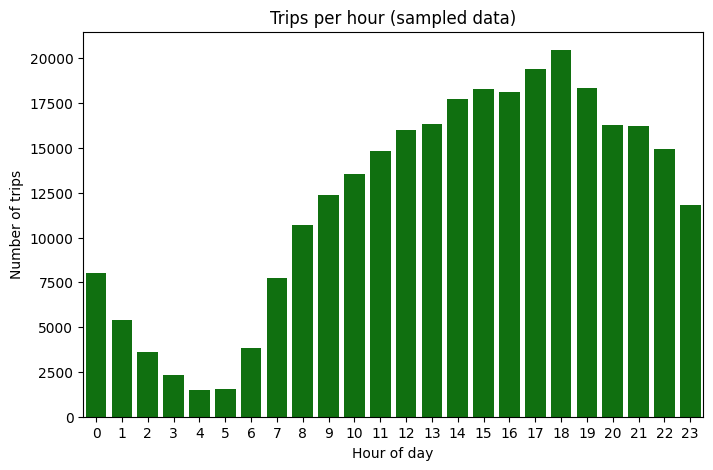

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=trips_per_hour, x="hour", y="trips", color='g')
plt.title("Trips per hour (sampled data)")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

top5_hours = trips_per_hour.sort_values("trips", ascending=False).head(5).copy()
top5_hours["estimated_actual_trips"] = (top5_hours["trips"] / sample_fraction).round().astype(int)

top5_hours

,hour,trips,estimated_actual_trips
18,18,20461,409220
17,17,19417,388340
19,19,18367,367340
15,15,18304,366080
16,16,18126,362520


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

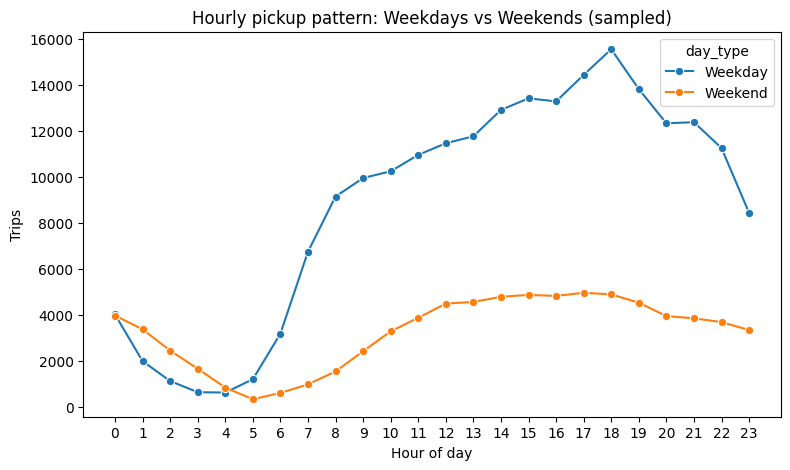

In [ ]:
# Compare traffic trends for the week days and weekends
df_traffic = df_eda.copy()
df_traffic["pickup_hour"] = df_traffic["tpep_pickup_datetime"].dt.hour
df_traffic["is_weekend"] = df_traffic["tpep_pickup_datetime"].dt.dayofweek >= 5

hourly_week = (
    df_traffic.groupby(["pickup_hour", "is_weekend"])
    .size()
    .reset_index(name="trips")
)
hourly_week["day_type"] = hourly_week["is_weekend"].map({False: "Weekday", True: "Weekend"})

plt.figure(figsize=(9,5))
sns.lineplot(data=hourly_week, x="pickup_hour", y="trips", hue="day_type", marker="o")
plt.title("Hourly pickup pattern: Weekdays vs Weekends (sampled)")
plt.xlabel("Hour of day")
plt.ylabel("Trips")
plt.xticks(range(0,24))
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones
df_top10 = df_eda_merged.copy()
df_top10["pickup_hour"] = df_top10["tpep_pickup_datetime"].dt.hour

# Add dropoff zone/borough as well (since df_eda_merged has only PU_zone/PU_borough)
df_top10 = (
    df_top10.merge(
        zones[["LocationID", "zone", "borough"]],
        left_on="DOLocationID",
        right_on="LocationID",
        how="left"
    )
    .rename(columns={"zone": "DO_zone", "borough": "DO_borough"})
    .drop(columns=["LocationID"])
)

# Top 10 pickup & dropoff IDs (overall)
top10_pickup = df_top10["PULocationID"].value_counts().head(10).index.tolist()
top10_dropoff = df_top10["DOLocationID"].value_counts().head(10).index.tolist()

# Hourly pickups in top pickup zones (with zone names)
pu_hourly = (
    df_top10[df_top10["PULocationID"].isin(top10_pickup)]
    .groupby(["pickup_hour", "PULocationID", "PU_zone", "PU_borough"])
    .size()
    .reset_index(name="pickups")
)

# Hourly dropoffs in top dropoff zones (with zone names)
do_hourly = (
    df_top10[df_top10["DOLocationID"].isin(top10_dropoff)]
    .groupby(["pickup_hour", "DOLocationID", "DO_zone", "DO_borough"])
    .size()
    .reset_index(name="dropoffs")
)

pu_hourly.head(), do_hourly.head()

(   pickup_hour  PULocationID              PU_zone PU_borough  pickups
 0            0           132          JFK Airport     Queens      617
 1            0           138    LaGuardia Airport     Queens      279
 2            0           142  Lincoln Square East  Manhattan      160
 3            0           161       Midtown Center  Manhattan      226
 4            0           162         Midtown East  Manhattan      173,
    pickup_hour  DOLocationID              DO_zone DO_borough  dropoffs
 0            0            68         East Chelsea  Manhattan       237
 1            0           141      Lenox Hill West  Manhattan       202
 2            0           142  Lincoln Square East  Manhattan       145
 3            0           161       Midtown Center  Manhattan       102
 4            0           162         Midtown East  Manhattan       135)

In [ ]:
# Top 10 Pickup Zones
pu_hourly['PU_zone'].head(10)

,PU_zone
0,JFK Airport
1,LaGuardia Airport
2,Lincoln Square East
3,Midtown Center
4,Midtown East
5,Murray Hill
6,Penn Station/Madison Sq West
7,Times Sq/Theatre District
8,Upper East Side North
9,Upper East Side South


In [ ]:
# Top 10 Dropoff Zones
do_hourly['DO_zone'].head(10)

,DO_zone
0,East Chelsea
1,Lenox Hill West
2,Lincoln Square East
3,Midtown Center
4,Midtown East
5,Murray Hill
6,Times Sq/Theatre District
7,Upper East Side North
8,Upper East Side South
9,Upper West Side South


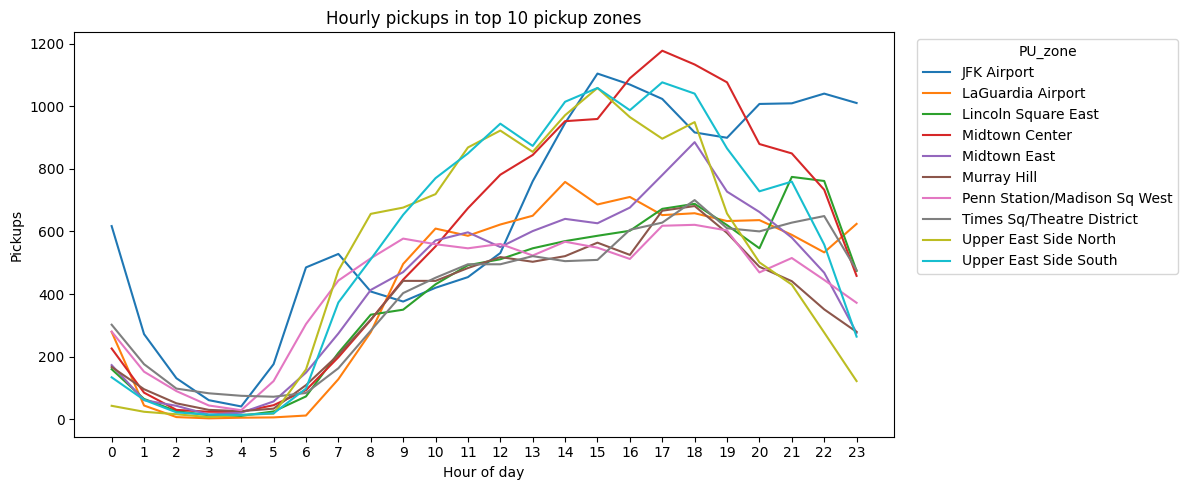

In [ ]:
# Show pickup trends in top 10 pickup zones
plt.figure(figsize=(12,5))
sns.lineplot(data=pu_hourly, x="pickup_hour", y="pickups", hue="PU_zone")
plt.title("Hourly pickups in top 10 pickup zones")
plt.xlabel("Hour of day")
plt.ylabel("Pickups")
plt.xticks(range(0,24))
plt.legend(title="PU_zone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

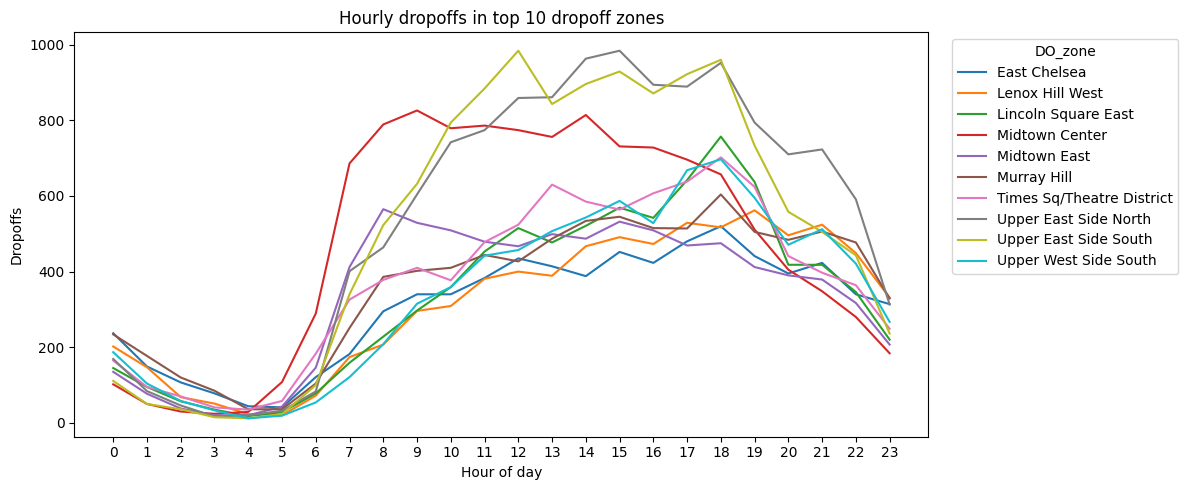

In [ ]:
# Show dropoff trends in top 10 dropoff zones
plt.figure(figsize=(12,5))
sns.lineplot(data=do_hourly, x="pickup_hour", y="dropoffs", hue="DO_zone")
plt.title("Hourly dropoffs in top 10 dropoff zones")
plt.xlabel("Hour of day")
plt.ylabel("Dropoffs")
plt.xticks(range(0,24))
plt.legend(title="DO_zone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pu_counts = df_top10["PULocationID"].value_counts().rename("pickups")
do_counts = df_top10["DOLocationID"].value_counts().rename("dropoffs")

ratio_df = pd.concat([pu_counts, do_counts], axis=1).fillna(0)
ratio_df["pickup_drop_ratio"] = ratio_df["pickups"] / ratio_df["dropoffs"].replace(0, pd.NA)
ratio_df = ratio_df.dropna(subset=["pickup_drop_ratio"])

# Make a unique LocationID -> zone mapping
zone_map = zones.drop_duplicates(subset=["LocationID"]).set_index("LocationID")["zone"]

ratio_df2 = ratio_df.reset_index().rename(columns={"index": "LocationID"})
ratio_df2["zone"] = ratio_df2["LocationID"].map(zone_map)

# Put zone first
ratio_df2 = ratio_df2[["zone", "LocationID", "pickups", "dropoffs", "pickup_drop_ratio"]]

top10_ratio = ratio_df2.sort_values("pickup_drop_ratio", ascending=False).head(10).reset_index(drop=True)
bottom10_ratio = ratio_df2.sort_values("pickup_drop_ratio", ascending=True).head(10).reset_index(drop=True)

In [ ]:
top10_ratio

,zone,LocationID,pickups,dropoffs,pickup_drop_ratio
0,East Elmhurst,70,1310.0,160,8.187500
1,JFK Airport,132,15283.0,3275,4.666565
2,LaGuardia Airport,138,10204.0,3533,2.888197
3,Penn Station/Madison Sq West,186,10013.0,6505,1.539277
4,Central Park,43,5025.0,3538,1.420294
5,Greenwich Village South,114,3804.0,2740,1.388321
6,West Village,249,6482.0,4760,1.361765
7,Midtown East,162,10315.0,8116,1.270946
8,Midtown Center,161,13644.0,11382,1.198735
9,Lincoln Square East,142,9541.0,8014,1.190542


In [ ]:
bottom10_ratio

,zone,LocationID,pickups,dropoffs,pickup_drop_ratio
0,Oakwood,176,0.0,1,0.0
1,Great Kills,109,0.0,4,0.0
2,New Dorp/Midland Beach,172,0.0,2,0.0
3,Mariners Harbor,156,0.0,6,0.0
4,Broad Channel,30,0.0,5,0.0
5,West Brighton,245,0.0,6,0.0
6,City Island,46,0.0,7,0.0
7,NaN,57,0.0,4,0.0
8,Stapleton,221,0.0,3,0.0
9,Van Cortlandt Park,240,0.0,6,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df_top10[(df_top10["pickup_hour"] >= 23) | (df_top10["pickup_hour"] <= 5)]

top10_night_pickup = night_df["PULocationID"].value_counts().head(10).reset_index()
top10_night_pickup.columns = ["PULocationID", "night_pickups"]
top10_night_pickup = top10_night_pickup.merge(zone_map, left_on="PULocationID", right_on="LocationID", how="left")
top10_night_pickup = top10_night_pickup[["zone", "PULocationID", "night_pickups"]]

top10_night_dropoff = night_df["DOLocationID"].value_counts().head(10).reset_index()
top10_night_dropoff.columns = ["DOLocationID", "night_dropoffs"]
top10_night_dropoff = top10_night_dropoff.merge(zone_map, left_on="DOLocationID", right_on="LocationID", how="left")
top10_night_dropoff = top10_night_dropoff[["zone", "DOLocationID", "night_dropoffs"]]

In [ ]:
top10_night_pickup

,zone,PULocationID,night_pickups
0,East Village,79,2497
1,JFK Airport,132,2308
2,West Village,249,1939
3,Clinton East,48,1704
4,Lower East Side,148,1571
5,Greenwich Village South,114,1364
6,Times Sq/Theatre District,230,1282
7,Penn Station/Madison Sq West,186,1089
8,LaGuardia Airport,138,968
9,Midtown South,164,963


In [ ]:
top10_night_dropoff

,zone,DOLocationID,night_dropoffs
0,East Village,79,1345
1,Clinton East,48,1093
2,Murray Hill,170,1017
3,East Chelsea,68,970
4,Gramercy,107,880
5,Lenox Hill West,141,842
6,West Village,249,786
7,Times Sq/Theatre District,230,713
8,Yorkville West,263,713
9,Sutton Place/Turtle Bay North,229,695


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
df_rev = df_eda.copy()
df_rev["pickup_hour"] = df_rev["tpep_pickup_datetime"].dt.hour

night_mask = (df_rev["pickup_hour"] >= 23) | (df_rev["pickup_hour"] <= 5)

night_revenue = df_rev.loc[night_mask, "total_amount"].sum()
day_revenue = df_rev.loc[~night_mask, "total_amount"].sum()

rev_share = pd.DataFrame({
    "time_period": ["night (11PM-5AM)", "day (6AM-10PM)"],
    "revenue": [night_revenue, day_revenue]
})
rev_share["revenue_share"] = rev_share["revenue"] / rev_share["revenue"].sum()

rev_share


,time_period,revenue,revenue_share
0,night (11PM-5AM),1001365.51,0.120491
1,day (6AM-10PM),7309339.61,0.879509


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts
df_diff_pass_counts = df_eda.copy()
df_diff_pass_counts= df_diff_pass_counts[(df_diff_pass_counts["trip_distance"] > 0) & (df_diff_pass_counts["passenger_count"] > 0)]

df_diff_pass_counts["fare_per_mile"] = df_diff_pass_counts["fare_amount"] / df_diff_pass_counts["trip_distance"]
df_diff_pass_counts["fare_per_mile_per_passenger"] = df_diff_pass_counts["fare_per_mile"] / df_diff_pass_counts["passenger_count"]

fare_per_pass = (
    df_diff_pass_counts.groupby("passenger_count")["fare_per_mile_per_passenger"]
    .mean()
    .reset_index()
    .rename(columns={"fare_per_mile_per_passenger": "avg_fare_per_mile_per_passenger"})
)

fare_per_pass

,passenger_count,avg_fare_per_mile_per_passenger
0,1.0,10.793718
1,2.0,5.947578
2,3.0,3.163639
3,4.0,3.391669
4,5.0,1.857500
5,6.0,1.357413


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
df_tm = df_eda.copy()
df_tm = df_tm[df_tm["trip_distance"] > 0]

df_tm["fare_per_mile"] = df_tm["fare_amount"] / df_tm["trip_distance"]
df_tm["pickup_hour"] = df_tm["tpep_pickup_datetime"].dt.hour
df_tm["day_name"] = df_tm["tpep_pickup_datetime"].dt.day_name()

avg_fare_hour = df_tm.groupby("pickup_hour")["fare_per_mile"].mean().reset_index()
avg_fare_day = df_tm.groupby("day_name")["fare_per_mile"].mean().reset_index()

avg_fare_day = avg_fare_day.set_index("day_name").reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).reset_index()

In [ ]:
avg_fare_hour

,pickup_hour,fare_per_mile
0,0,9.682258
1,1,9.458993
2,2,9.320798
3,3,10.377316
4,4,8.244206
5,5,8.803815
6,6,11.906846
7,7,9.849446
8,8,9.820113
9,9,11.594143


In [ ]:
avg_fare_day

,day_name,fare_per_mile
0,Monday,10.249257
1,Tuesday,10.774885
2,Wednesday,11.315515
3,Thursday,10.471017
4,Friday,11.561379
5,Saturday,10.524791
6,Sunday,11.578242


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors
df_v = df_eda.copy()
df_v = df_v[df_v["trip_distance"] > 0]

df_v["fare_per_mile"] = df_v["fare_amount"] / df_v["trip_distance"]
df_v["pickup_hour"] = df_v["tpep_pickup_datetime"].dt.hour

vendor_hour = (
    df_v.groupby(["VendorID", "pickup_hour"])["fare_per_mile"]
    .mean()
    .reset_index()
    .rename(columns={"fare_per_mile": "avg_fare_per_mile"})
)

vendor_hour

,VendorID,pickup_hour,avg_fare_per_mile
0,1,0,6.759202
1,1,1,7.339801
2,1,2,6.426627
3,1,3,6.232090
4,1,4,6.068725
5,1,5,6.360576
6,1,6,6.648067
7,1,7,7.195278
8,1,8,8.505629
9,1,9,8.386043


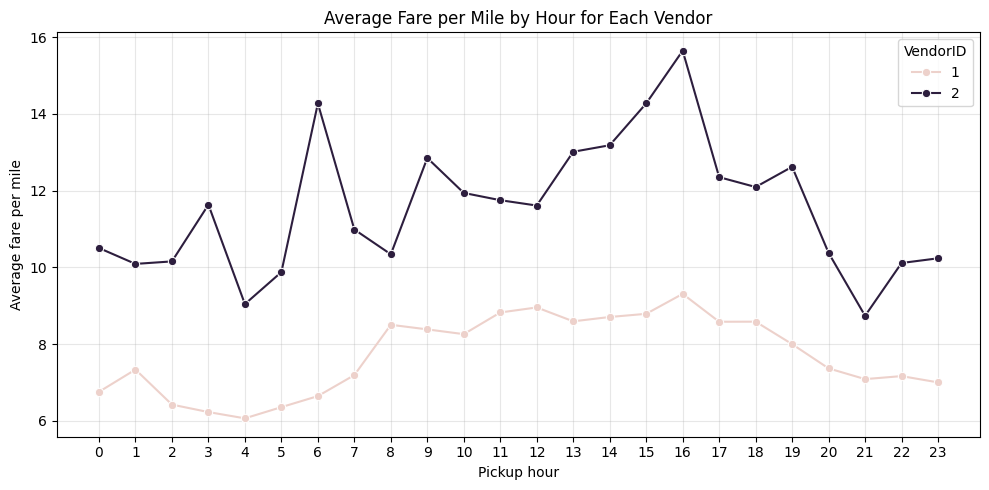

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=vendor_hour,
    x="pickup_hour",
    y="avg_fare_per_mile",
    hue="VendorID",
    marker="o"
)

plt.title("Average Fare per Mile by Hour for Each Vendor")
plt.xlabel("Pickup hour")
plt.ylabel("Average fare per mile")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title="VendorID")
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers
df_tier = df_eda.copy()
df_tier = df_tier[df_tier["trip_distance"] > 0]

df_tier["fare_per_mile"] = df_tier["fare_amount"] / df_tier["trip_distance"]

df_tier["distance_tier"] = pd.cut(
    df_tier["trip_distance"],
    bins=[0, 2, 5, float("inf")],
    labels=["0-2 miles", "2-5 miles", ">5 miles"],
    right=True
)

tier_vendor = (
    df_tier.groupby(["distance_tier", "VendorID"])["fare_per_mile"]
    .mean()
    .reset_index()
    .rename(columns={"fare_per_mile": "avg_fare_per_mile"})
)

tier_vendor

,distance_tier,VendorID,avg_fare_per_mile
0,0-2 miles,1,9.991237
1,0-2 miles,2,17.031865
2,2-5 miles,1,6.377112
3,2-5 miles,2,6.549023
4,>5 miles,1,4.400109
5,>5 miles,2,4.502742


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_tip = df_eda.copy()

# Keep trips where tip% is meaningful
df_tip = df_tip[(df_tip["total_amount"] > 0) & (df_tip["fare_amount"] > 0)]

df_tip["tip_pct"] = (df_tip["tip_amount"] / df_tip["total_amount"]) * 100
df_tip["pickup_hour"] = df_tip["tpep_pickup_datetime"].dt.hour

# Distance buckets
df_tip["distance_bucket"] = pd.cut(
    df_tip["trip_distance"],
    bins=[0, 2, 5, 10, np.inf],
    labels=["0-2", "2-5", "5-10", "10+"],
    include_lowest=True
)

tip_by_distance = df_tip.groupby("distance_bucket")["tip_pct"].mean().reset_index(name="avg_tip_percentage")
tip_by_passengers = df_tip.groupby("passenger_count")["tip_pct"].mean().reset_index(name="avg_tip_percentage")
tip_by_hour = df_tip.groupby("pickup_hour")["tip_pct"].mean().reset_index(name="avg_tip_percentaget")

In [ ]:
tip_by_distance

,distance_bucket,avg_tip_percentage
0,0-2,12.014161
1,2-5,12.290606
2,5-10,11.563488
3,10+,11.030475


In [ ]:
tip_by_passengers

,passenger_count,avg_tip_percentage
0,1.0,12.075610
1,2.0,11.794944
2,3.0,11.229256
3,4.0,10.480406
4,5.0,11.874448
5,6.0,12.220562


In [ ]:
tip_by_hour

,pickup_hour,avg_tip_percentaget
0,0,11.865177
1,1,11.950898
2,2,11.718169
3,3,11.612025
4,4,10.209770
5,5,10.054366
6,6,11.102940
7,7,11.934015
8,8,12.167907
9,9,11.905032


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = df_tip[df_tip["tip_pct"] < 10].copy()
high_tip = df_tip[df_tip["tip_pct"] > 25].copy()

compare_summary = pd.DataFrame({
    "group": ["low_tip(<10%)", "high_tip(>25%)"],
    "count": [len(low_tip), len(high_tip)],
    "avg_distance": [low_tip["trip_distance"].mean(), high_tip["trip_distance"].mean()],
    "avg_fare": [low_tip["fare_amount"].mean(), high_tip["fare_amount"].mean()],
    "avg_total": [low_tip["total_amount"].mean(), high_tip["total_amount"].mean()],
    "avg_passengers": [low_tip["passenger_count"].mean(), high_tip["passenger_count"].mean()],
    "avg_pickup_hour": [low_tip["pickup_hour"].mean(), high_tip["pickup_hour"].mean()],
})
compare_summary

,group,count,avg_distance,avg_fare,avg_total,avg_passengers,avg_pickup_hour
0,low_tip(<10%),97611,3.556103,20.499183,26.533482,1.406911,14.036850
1,high_tip(>25%),1481,1.761175,12.113707,25.939642,1.334909,13.492235


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days
df_pass_count = df_eda.copy()
df_pass_count["pickup_hour"] = df_pass_count["tpep_pickup_datetime"].dt.hour
df_pass_count["day_name"] = df_pass_count["tpep_pickup_datetime"].dt.day_name()

order_days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

pass_count_hour = df_pass_count.groupby("pickup_hour")["passenger_count"].mean().reset_index(name="avg_passenger_count")
pass_count_day = (
    df_pass_count.groupby("day_name")["passenger_count"].mean()
    .reindex(order_days)
    .reset_index(name="avg_passenger_count")
)

In [ ]:
pass_count_hour

,pickup_hour,avg_passenger_count
0,0,1.426092
1,1,1.425892
2,2,1.458971
3,3,1.481689
4,4,1.403237
5,5,1.271208
6,6,1.242718
7,7,1.281436
8,8,1.281778
9,9,1.322625


In [ ]:
pass_count_day

,day_name,avg_passenger_count
0,Monday,1.359475
1,Tuesday,1.331551
2,Wednesday,1.326038
3,Thursday,1.341648
4,Friday,1.400863
5,Saturday,1.483281
6,Sunday,1.459015


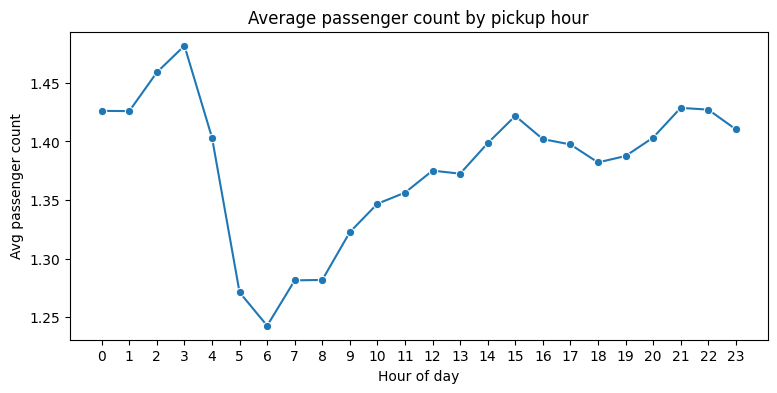

In [ ]:
plt.figure(figsize=(9,4))
sns.lineplot(data=pass_count_hour, x="pickup_hour", y="avg_passenger_count", marker="o")
plt.title("Average passenger count by pickup hour")
plt.xlabel("Hour of day")
plt.ylabel("Avg passenger count")
plt.xticks(range(0,24))
plt.show()

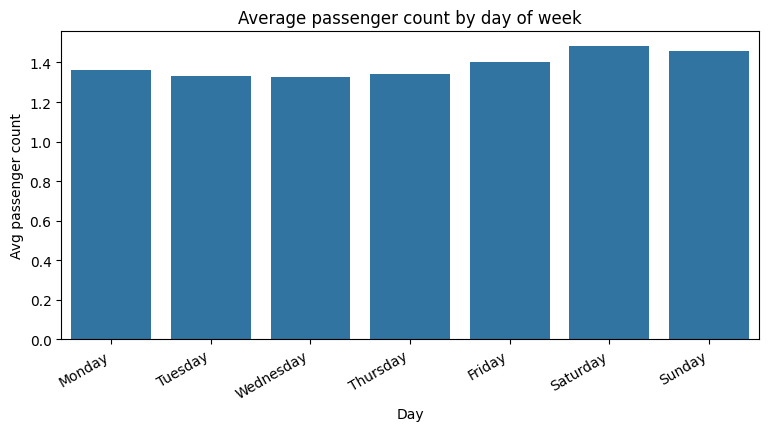

In [ ]:
plt.figure(figsize=(9,4))
sns.barplot(data=pass_count_day, x="day_name", y="avg_passenger_count")
plt.title("Average passenger count by day of week")
plt.xlabel("Day")
plt.ylabel("Avg passenger count")
plt.xticks(rotation=30, ha="right")
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones
pass_count_by_zone = (
    df_eda_merged.groupby(["PULocationID", "PU_zone", "PU_borough"])["passenger_count"]
    .mean()
    .reset_index(name="avg_passenger_count")
    .sort_values("avg_passenger_count", ascending=False)
)

pass_count_by_zone.head(20)

,PULocationID,PU_zone,PU_borough,avg_passenger_count
52,58,Country Club,Bronx,3.000000
53,59,Crotona Park,Bronx,2.000000
98,111,Green-Wood Cemetery,Brooklyn,2.000000
114,128,Inwood Hill Park,Manhattan,2.000000
178,195,Red Hook,Brooklyn,1.793103
10,12,Battery Park,Manhattan,1.789916
60,66,DUMBO/Vinegar Hill,Brooklyn,1.666667
4,6,Arrochar/Fort Wadsworth,Staten Island,1.666667
117,131,Jamaica Estates,Queens,1.625000
44,49,Clinton Hill,Brooklyn,1.600000


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_pc_map = pass_count_by_zone[["PULocationID", "avg_passenger_count"]].rename(columns={"PULocationID": "LocationID"})

zones_with_trips_pc = zones_with_trips.merge(avg_pc_map, on="LocationID", how="left")
zones_with_trips_pc["avg_passenger_count"] = zones_with_trips_pc["avg_passenger_count"].fillna(0)

zones_with_trips_pc[["LocationID", "zone", "borough", "avg_passenger_count"]].head()

,LocationID,zone,borough,avg_passenger_count
0,1,Newark Airport,EWR,1.424242
1,2,Jamaica Bay,Queens,0.000000
2,3,Allerton/Pelham Gardens,Bronx,1.000000
3,4,Alphabet City,Manhattan,1.459807
4,5,Arden Heights,Staten Island,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?
df_sc = df_eda.copy()
df_sc["pickup_hour"] = df_sc["tpep_pickup_datetime"].dt.hour

surcharge_cols = ["extra", "mta_tax", "tolls_amount", "improvement_surcharge", "congestion_surcharge", "airport_fee"]

surcharge_freq = pd.DataFrame({
    "surcharge": surcharge_cols,
    "applied_count": [(df_sc[c] > 0).sum() for c in surcharge_cols],
    "applied_percentage": [((df_sc[c] > 0).mean() * 100) for c in surcharge_cols]
}).sort_values("applied_count", ascending=False)

surcharge_freq

,surcharge,applied_count,applied_percentage
3,improvement_surcharge,289314,99.963030
1,mta_tax,286886,99.124113
4,congestion_surcharge,267384,92.385832
0,extra,179354,61.969933
5,airport_fee,25417,8.782017
2,tolls_amount,23446,8.101002


In [ ]:
extra_by_hour = df_sc.groupby("pickup_hour")["extra"].apply(lambda s: (s > 0).mean() * 100).reset_index(name="percentage_extra_applied")

extra_by_puzone = (
    df_eda_merged.groupby(["PULocationID", "PU_zone"])["extra"]
    .apply(lambda s: (s > 0).mean() * 100)
    .reset_index(name="percentage_extra_applied")
    .sort_values("percentage_extra_applied", ascending=False)
)

In [ ]:
extra_by_hour.head()

,pickup_hour,percentage_extra_applied
0,0,95.742821
1,1,97.139673
2,2,96.968011
3,3,96.897889
4,4,90.424815


In [ ]:
extra_by_puzone.head(15)

,PULocationID,PU_zone,percentage_extra_applied
6,8,Astoria Park,100.000000
53,59,Crotona Park,100.000000
170,187,Port Richmond,100.000000
124,138,LaGuardia Airport,98.547025
134,148,Lower East Side,83.361515
64,70,East Elmhurst,82.645260
101,114,Greenwich Village South,79.642294
234,256,Williamsburg (South Side),79.032258
73,79,East Village,77.306733
2,4,Alphabet City,76.527331


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

- I used route-hour level speeds, computed as `avg_speed_mph = avg_distance / (avg_duration_min / 60)`, to flag the slowest corridors by `pickup_hour`.
- I would avoid dispatching drivers into route-hour pairs with very low `avg_speed_mph` during peak periods, and instead reroute supply through nearby faster corridors to improve trips per hour.
- I also used `trips` per route-hour as a reliability check so decisions prioritize congestion patterns that occur frequently, not one-off anomalies.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

- Demand peaked in the evening, with the busiest hour at `18` (6 PM) with **20,461 sampled pickups** (about **409,220** scaled using `sample_fraction = 0.05`), so I would stage the largest fleet buffer before `17` to `19`.
- I would keep strong coverage around high-demand zones like **JFK Airport (15,250)**, **Upper East Side South (13,686)**, **Midtown Center (13,643)**, and **LaGuardia Airport (10,186)** since they repeatedly appeared among the busiest pickup areas.
- For night hours `23` to `5`, I would shift supply toward zones with the highest night activity like **East Village (2,497 night pickups)** and **JFK Airport (2,308 night pickups)** to reduce wait times while maintaining utilization.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

- Since fare was strongly distance-driven (`corr(trip_distance, fare_amount) = 0.9456`), I would anchor pricing decisions primarily on `trip_distance` and time-of-day patterns, not on `passenger_count` because `corr = 0.0454`.
- Vendor pricing differed sharply on short trips, where `0-2 miles` had **Vendor 1: 9.99** vs **Vendor 2: 17.03** average `fare_per_mile`, so I would tighten short-trip pricing bands during peak hours to stay competitive.
- I would preserve margins on longer trips where vendors converged (`>5 miles` was about **4.40 to 4.50** `avg_fare_per_mile`), and focus on operational improvements (better ETAs, less congestion exposure) to support better tip behavior since `corr(tip_amount, trip_distance) = 0.5957`